# Telstra Network Disruptions — Graph Analysis

This notebook explores the disruption dataset **as it lives in Neo4j**. Every figure is
driven by a Cypher query through the shared `neo4j_analysis.Neo4jAnalysis` helper, so the
analysis reflects the graph model (events, locations, log features, severities, and the
`NEXT_EVENT` cascade) rather than the flat CSVs.

We look at the data from several angles:

1. Graph size & schema
2. The target — `fault_severity`
3. The alarm severity vs. the realised fault severity
4. Locations — where the volume and the risk sit
5. Log features that flag severe faults
6. Resource & event types
7. How events cluster across the network
8. The `NEXT_EVENT` cascade and whether topology carries risk signal
9. A rendered subgraph of one busy location


In [1]:
# Setup
from dotenv import load_dotenv
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from neo4j_analysis import Neo4jAnalysis

load_dotenv()
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

graph = Neo4jAnalysis(
    os.getenv("NEO4J_URI"),
    os.getenv("NEO4J_USERNAME"),
    os.getenv("NEO4J_PASSWORD"),
    os.getenv("NEO4J_DATABASE"),
)
assert graph.verify_connection(), "Could not connect to Neo4j — run loader.ipynb first"
print("Connected.")

Connected.


## 1. Graph size & schema

A quick census of the graph. The relationship counts mirror the cardinalities in the
source data: one alarm and one location per event, but many log features, event types and
resource types.

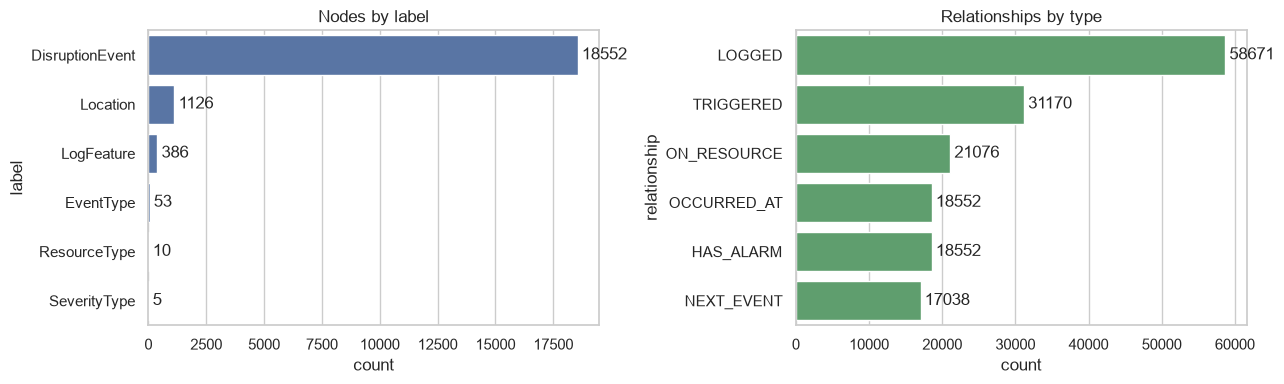

,label,count
0,DisruptionEvent,18552
1,Location,1126
2,LogFeature,386
3,EventType,53
4,ResourceType,10
5,SeverityType,5


,relationship,count
0,LOGGED,58671
1,TRIGGERED,31170
2,ON_RESOURCE,21076
3,OCCURRED_AT,18552
4,HAS_ALARM,18552
5,NEXT_EVENT,17038


In [2]:
nodes = graph.run_query_df(
    "MATCH (n) UNWIND labels(n) AS label "
    "RETURN label, count(*) AS count ORDER BY count DESC"
)
rels = graph.run_query_df(
    "MATCH ()-[r]->() RETURN type(r) AS relationship, count(*) AS count ORDER BY count DESC"
)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=nodes, y="label", x="count", ax=ax[0], color="#4C72B0")
ax[0].set_title("Nodes by label")
sns.barplot(data=rels, y="relationship", x="count", ax=ax[1], color="#55A868")
ax[1].set_title("Relationships by type")
for a in ax:
    a.bar_label(a.containers[0], fmt="%d", padding=3)
plt.tight_layout(); plt.show()
display(nodes); display(rels)

## 2. The target: `fault_severity`

`fault_severity` is only known for the **train** split and takes three values:
`0` = no reported fault, `1` = a few, `2` = many. The classes are heavily imbalanced —
roughly two-thirds of events are `0` — which any model (and its evaluation) must respect.

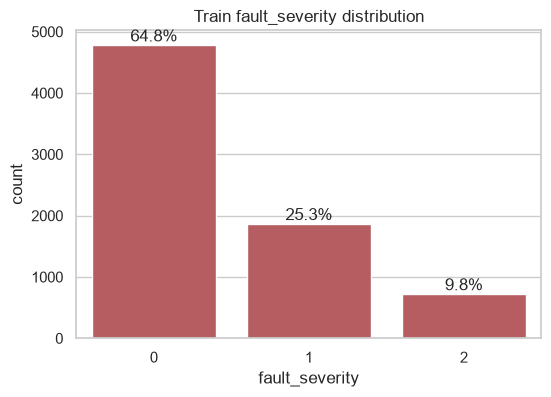

,fault_severity,count,pct
0,0,4784,64.815
1,1,1871,25.349
2,2,726,9.836


In [3]:
target = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})
    RETURN e.fault_severity AS fault_severity, count(*) AS count
    ORDER BY fault_severity
''')
target["pct"] = 100 * target["count"] / target["count"].sum()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=target, x="fault_severity", y="count", ax=ax, color="#C44E52")
ax.bar_label(ax.containers[0], labels=[f"{p:.1f}%" for p in target["pct"]])
ax.set_title("Train fault_severity distribution")
plt.show()
display(target)

## 3. Alarm severity vs. realised fault severity

`severity_type` is the *internal warning level of the log message* — set when the alarm
fires. It is **not** the outcome. Cross-tabulating it against `fault_severity` shows how
predictive the raw alarm level is. Some severity types skew much more towards severe
faults than others, but no single alarm level cleanly separates the classes.

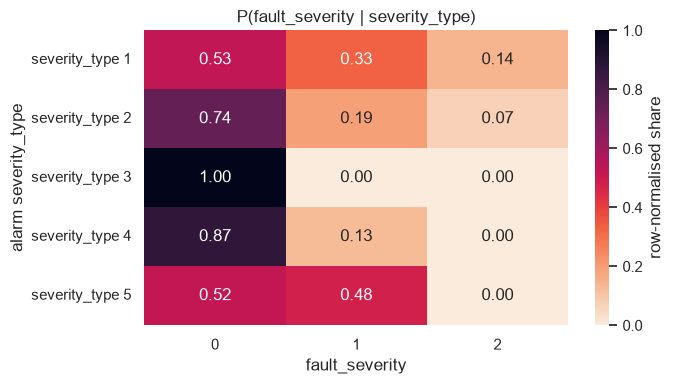

fault_severity,0,1,2,events
severity_type,,,,
severity_type 1,1778,1117,480,3375
severity_type 2,2652,693,246,3591
severity_type 3,4,0,0,4
severity_type 4,338,50,0,388
severity_type 5,12,11,0,23


In [4]:
sev = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[:HAS_ALARM]->(s:SeverityType)
    RETURN s.name AS severity_type, e.fault_severity AS fault_severity, count(*) AS count
''')
pivot = (sev.pivot_table(index="severity_type", columns="fault_severity",
                         values="count", aggfunc="sum", fill_value=0)
            .sort_index())
prop = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(prop, annot=True, fmt=".2f", cmap="rocket_r", ax=ax,
            cbar_kws={"label": "row-normalised share"})
ax.set_title("P(fault_severity | severity_type)")
ax.set_xlabel("fault_severity"); ax.set_ylabel("alarm severity_type")
plt.tight_layout(); plt.show()
display(pivot.assign(events=pivot.sum(axis=1)))

## 4. Locations — where volume and risk live

Events are tied to ~1,100 locations. Two different questions: which locations are *busy*
(event volume), and which are *risky* (high mean fault severity). They are not the same —
a high-traffic site can be healthy, and a small site can be a chronic offender. We require
a minimum of 10 train events before trusting a location's risk estimate.

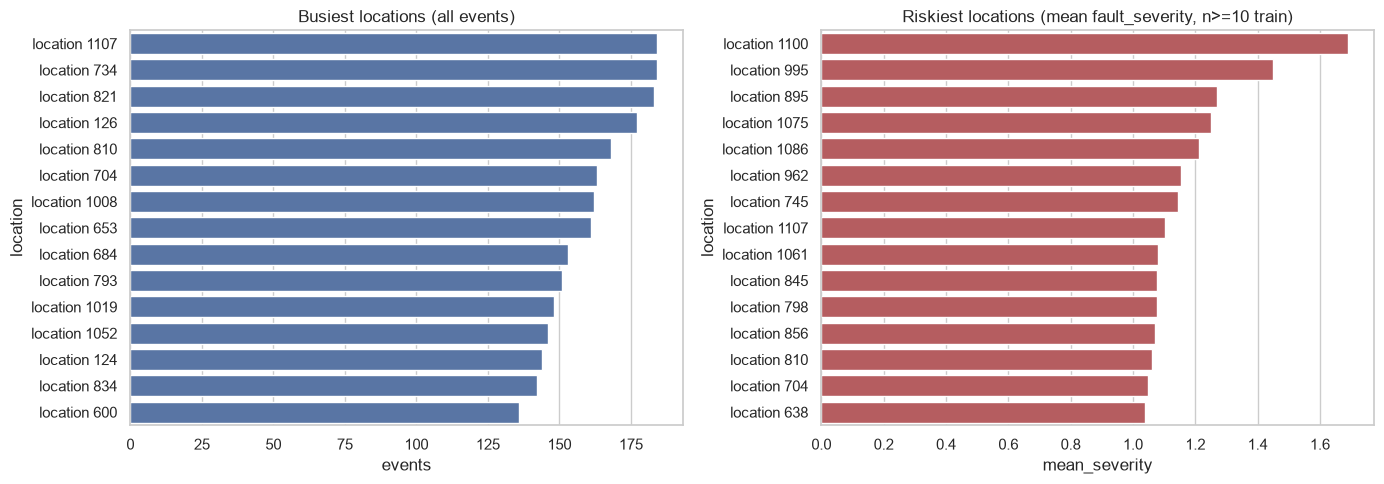

,location,n,mean_severity,pct_severe
0,location 1100,45,1.689,0.733
1,location 995,40,1.450,0.550
2,location 895,26,1.269,0.385
3,location 1075,28,1.250,0.429
4,location 1086,33,1.212,0.485
5,location 962,45,1.156,0.444
6,location 745,14,1.143,0.357
7,location 1107,78,1.103,0.423
8,location 1061,25,1.080,0.360
9,location 845,39,1.077,0.385


In [5]:
top_vol = graph.run_query_df('''
    MATCH (e:DisruptionEvent)-[:OCCURRED_AT]->(l:Location)
    RETURN l.name AS location, count(*) AS events,
           sum(CASE WHEN e.dataset='train' THEN 1 ELSE 0 END) AS train_events
    ORDER BY events DESC LIMIT 15
''')

risk = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[:OCCURRED_AT]->(l:Location)
    WITH l.name AS location, count(*) AS n,
         avg(toFloat(e.fault_severity)) AS mean_severity,
         sum(CASE WHEN e.fault_severity=2 THEN 1 ELSE 0 END)*1.0/count(*) AS pct_severe
    WHERE n >= 10
    RETURN location, n, mean_severity, pct_severe
    ORDER BY mean_severity DESC LIMIT 15
''')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=top_vol, y="location", x="events", ax=ax[0], color="#4C72B0")
ax[0].set_title("Busiest locations (all events)")
sns.barplot(data=risk, y="location", x="mean_severity", ax=ax[1], color="#C44E52")
ax[1].set_title("Riskiest locations (mean fault_severity, n>=10 train)")
plt.tight_layout(); plt.show()
display(risk)

## 5. Log features that flag severe faults

`log_feature` codes are the richest signal in the data. For every feature we measure its
**support** (how many train events logged it) and the **mean fault severity** of those
events. Sorting reveals features that are strong "severe-fault markers" and others that
are essentially benign — exactly the kind of contrast a model can exploit.

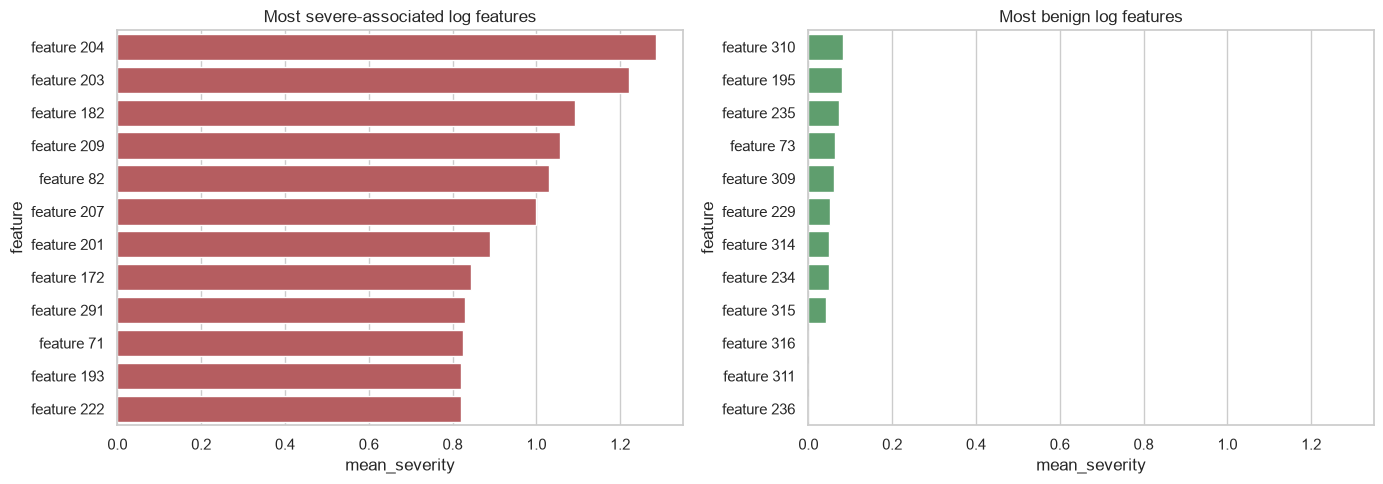

,fault_severity,avg_total_volume,avg_n_features,events
0,0,"171,932.000","15,584.000",1
1,1,"24,990.000","5,670.000",1
2,2,"37,943.000","2,597.000",1


In [6]:
feat = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[:LOGGED]->(f:LogFeature)
    WITH f.name AS feature, count(DISTINCT e) AS support,
         avg(toFloat(e.fault_severity)) AS mean_severity
    WHERE support >= 30
    RETURN feature, support, mean_severity
    ORDER BY mean_severity DESC
''')
top = feat.head(12); bottom = feat.tail(12)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.barplot(data=top, y="feature", x="mean_severity", ax=ax[0], color="#C44E52")
ax[0].set_title("Most severe-associated log features")
sns.barplot(data=bottom, y="feature", x="mean_severity", ax=ax[1], color="#55A868")
ax[1].set_title("Most benign log features")
plt.tight_layout(); plt.show()

# Does the *total logged volume* of an event track its severity?
vol = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[r:LOGGED]->(:LogFeature)
    WITH e.fault_severity AS fault_severity, sum(r.volume) AS total_volume,
         count(r) AS n_features
    RETURN fault_severity, avg(total_volume) AS avg_total_volume,
           avg(n_features) AS avg_n_features, count(*) AS events
    ORDER BY fault_severity
''')
display(vol)

## 6. Resource & event types

Coarser dimensions. There are only 10 resource types and ~50 event types. We rank each by
its association with severe faults (mean severity, with a support floor), which surfaces a
handful of resource types and event types that carry disproportionate risk.

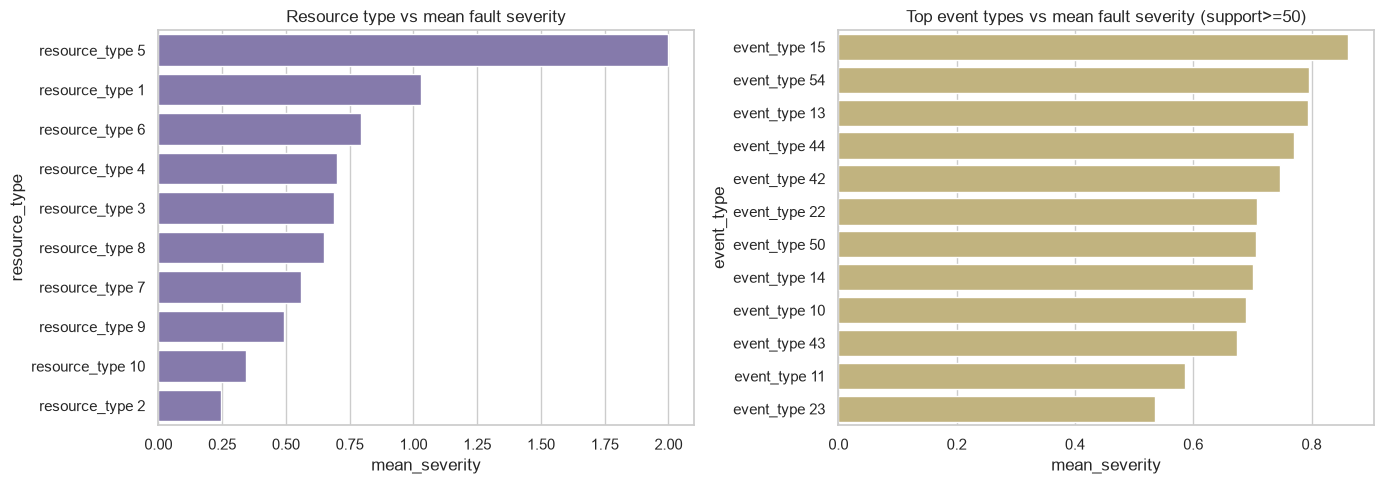

,resource_type,support,mean_severity
0,resource_type 5,4,2.000
1,resource_type 1,34,1.029
2,resource_type 6,247,0.794
3,resource_type 4,144,0.701
4,resource_type 3,58,0.690
5,resource_type 8,4051,0.650
6,resource_type 7,225,0.560
7,resource_type 9,77,0.494
8,resource_type 10,35,0.343
9,resource_type 2,3585,0.244


In [7]:
res = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[:ON_RESOURCE]->(r:ResourceType)
    WITH r.name AS resource_type, count(DISTINCT e) AS support,
         avg(toFloat(e.fault_severity)) AS mean_severity
    RETURN resource_type, support, mean_severity ORDER BY mean_severity DESC
''')
evt = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[:TRIGGERED]->(t:EventType)
    WITH t.name AS event_type, count(DISTINCT e) AS support,
         avg(toFloat(e.fault_severity)) AS mean_severity
    WHERE support >= 50
    RETURN event_type, support, mean_severity ORDER BY mean_severity DESC LIMIT 12
''')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=res, y="resource_type", x="mean_severity", ax=ax[0], color="#8172B3")
ax[0].set_title("Resource type vs mean fault severity")
sns.barplot(data=evt, y="event_type", x="mean_severity", ax=ax[1], color="#CCB974")
ax[1].set_title("Top event types vs mean fault severity (support>=50)")
plt.tight_layout(); plt.show()
display(res)

## 7. How events cluster across the network

A graph-native view: how many events pile up at the same location, and which log features
act as **hubs** that wire many events together. Hub features are shared by hundreds of
events, so they connect otherwise-unrelated disruptions into a dense co-occurrence
structure — the substrate the graph-feature model in `predictor.ipynb` will mine.

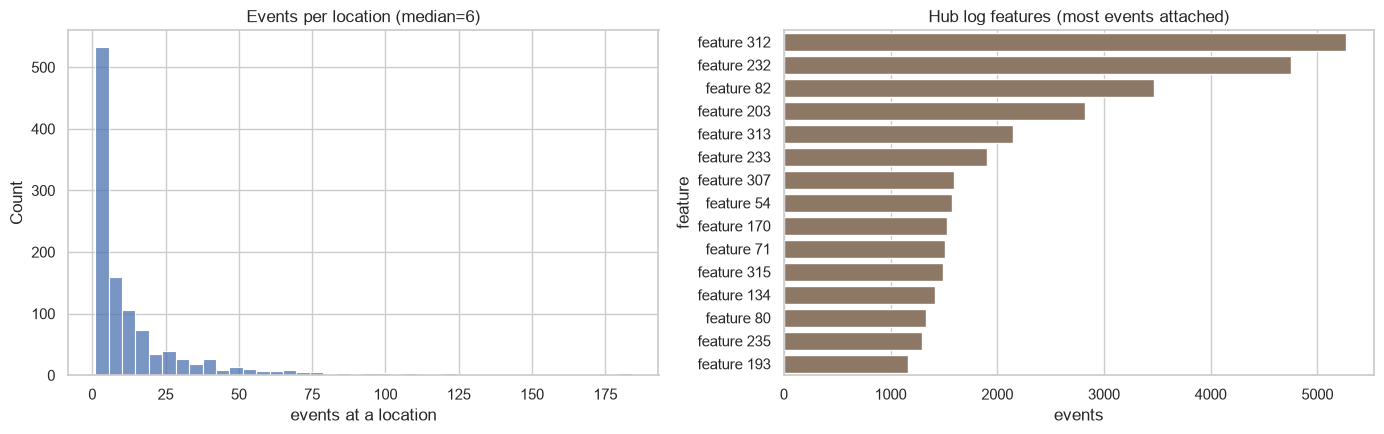

In [8]:
per_loc = graph.run_query_df('''
    MATCH (e:DisruptionEvent)-[:OCCURRED_AT]->(l:Location)
    RETURN l.name AS location, count(*) AS events
''')
hub_feats = graph.run_query_df('''
    MATCH (f:LogFeature)<-[:LOGGED]-(e:DisruptionEvent)
    RETURN f.name AS feature, count(e) AS events
    ORDER BY events DESC LIMIT 15
''')

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(per_loc["events"], bins=40, ax=ax[0], color="#4C72B0")
ax[0].set_title(f"Events per location (median={per_loc.events.median():.0f})")
ax[0].set_xlabel("events at a location")
sns.barplot(data=hub_feats, y="feature", x="events", ax=ax[1], color="#937860")
ax[1].set_title("Hub log features (most events attached)")
plt.tight_layout(); plt.show()

## 8. The `NEXT_EVENT` cascade — does topology carry risk?

`NEXT_EVENT` links the location of each event to the location of the next event by id, so
its weighted structure is a proxy for how faults ripple through the network. We score each
location by its **cascade strength** (total in + out `NEXT_EVENT` weight) and ask whether
busier cascade hubs also run hotter on fault severity. A non-trivial correlation here is
the justification for adding graph features to the model.

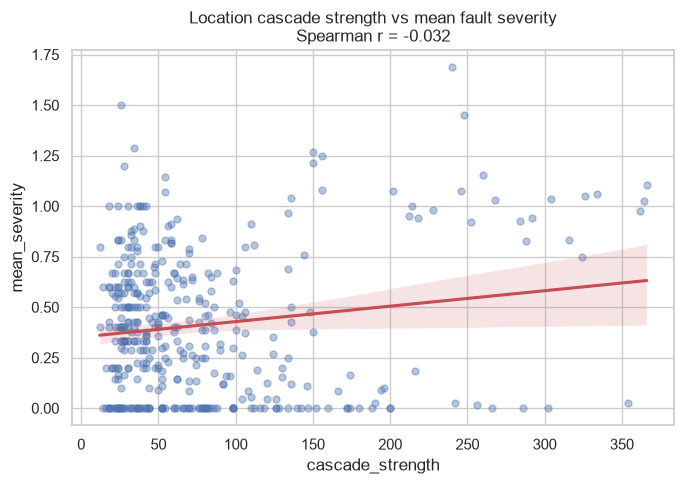

Strongest NEXT_EVENT transitions:


,from_location,to_location,weight
0,location 734,location 821,7
1,location 995,location 1107,6
2,location 821,location 793,6
3,location 124,location 821,5
4,location 684,location 734,4
5,location 684,location 1100,4
6,location 895,location 653,4
7,location 653,location 793,4
8,location 653,location 1100,4
9,location 704,location 684,4


In [9]:
casc = graph.run_query_df('''
    MATCH (l:Location)<-[:OCCURRED_AT]-(e:DisruptionEvent {dataset:'train'})
    WITH l, avg(toFloat(e.fault_severity)) AS mean_severity, count(e) AS n
    WHERE n >= 5
    OPTIONAL MATCH (l)-[o:NEXT_EVENT]->()
    WITH l, mean_severity, n, sum(o.weight) AS out_strength
    OPTIONAL MATCH (l)<-[i:NEXT_EVENT]-()
    WITH l, mean_severity, n, out_strength, sum(i.weight) AS in_strength
    RETURN l.name AS location, mean_severity, n,
           coalesce(out_strength,0) + coalesce(in_strength,0) AS cascade_strength
    ORDER BY cascade_strength DESC
''')

top_edges = graph.run_query_df('''
    MATCH (a:Location)-[r:NEXT_EVENT]->(b:Location)
    RETURN a.name AS from_location, b.name AS to_location, r.weight AS weight
    ORDER BY weight DESC LIMIT 10
''')

corr = casc["cascade_strength"].corr(casc["mean_severity"], method="spearman")
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=casc, x="cascade_strength", y="mean_severity", ax=ax,
            scatter_kws={"alpha": 0.4, "s": 25}, line_kws={"color": "#C44E52"})
ax.set_title(f"Location cascade strength vs mean fault severity\nSpearman r = {corr:.3f}")
plt.tight_layout(); plt.show()
print("Strongest NEXT_EVENT transitions:"); display(top_edges)

## 9. A rendered subgraph

Finally, a literal picture of the graph: one busy, fault-prone location, the disruption
events that occurred there, and the alarm severity of each. Rendered with `neo4j-viz` and
captured to a PNG via the helper in `neo4j_analysis.py`.

Visualising location 745


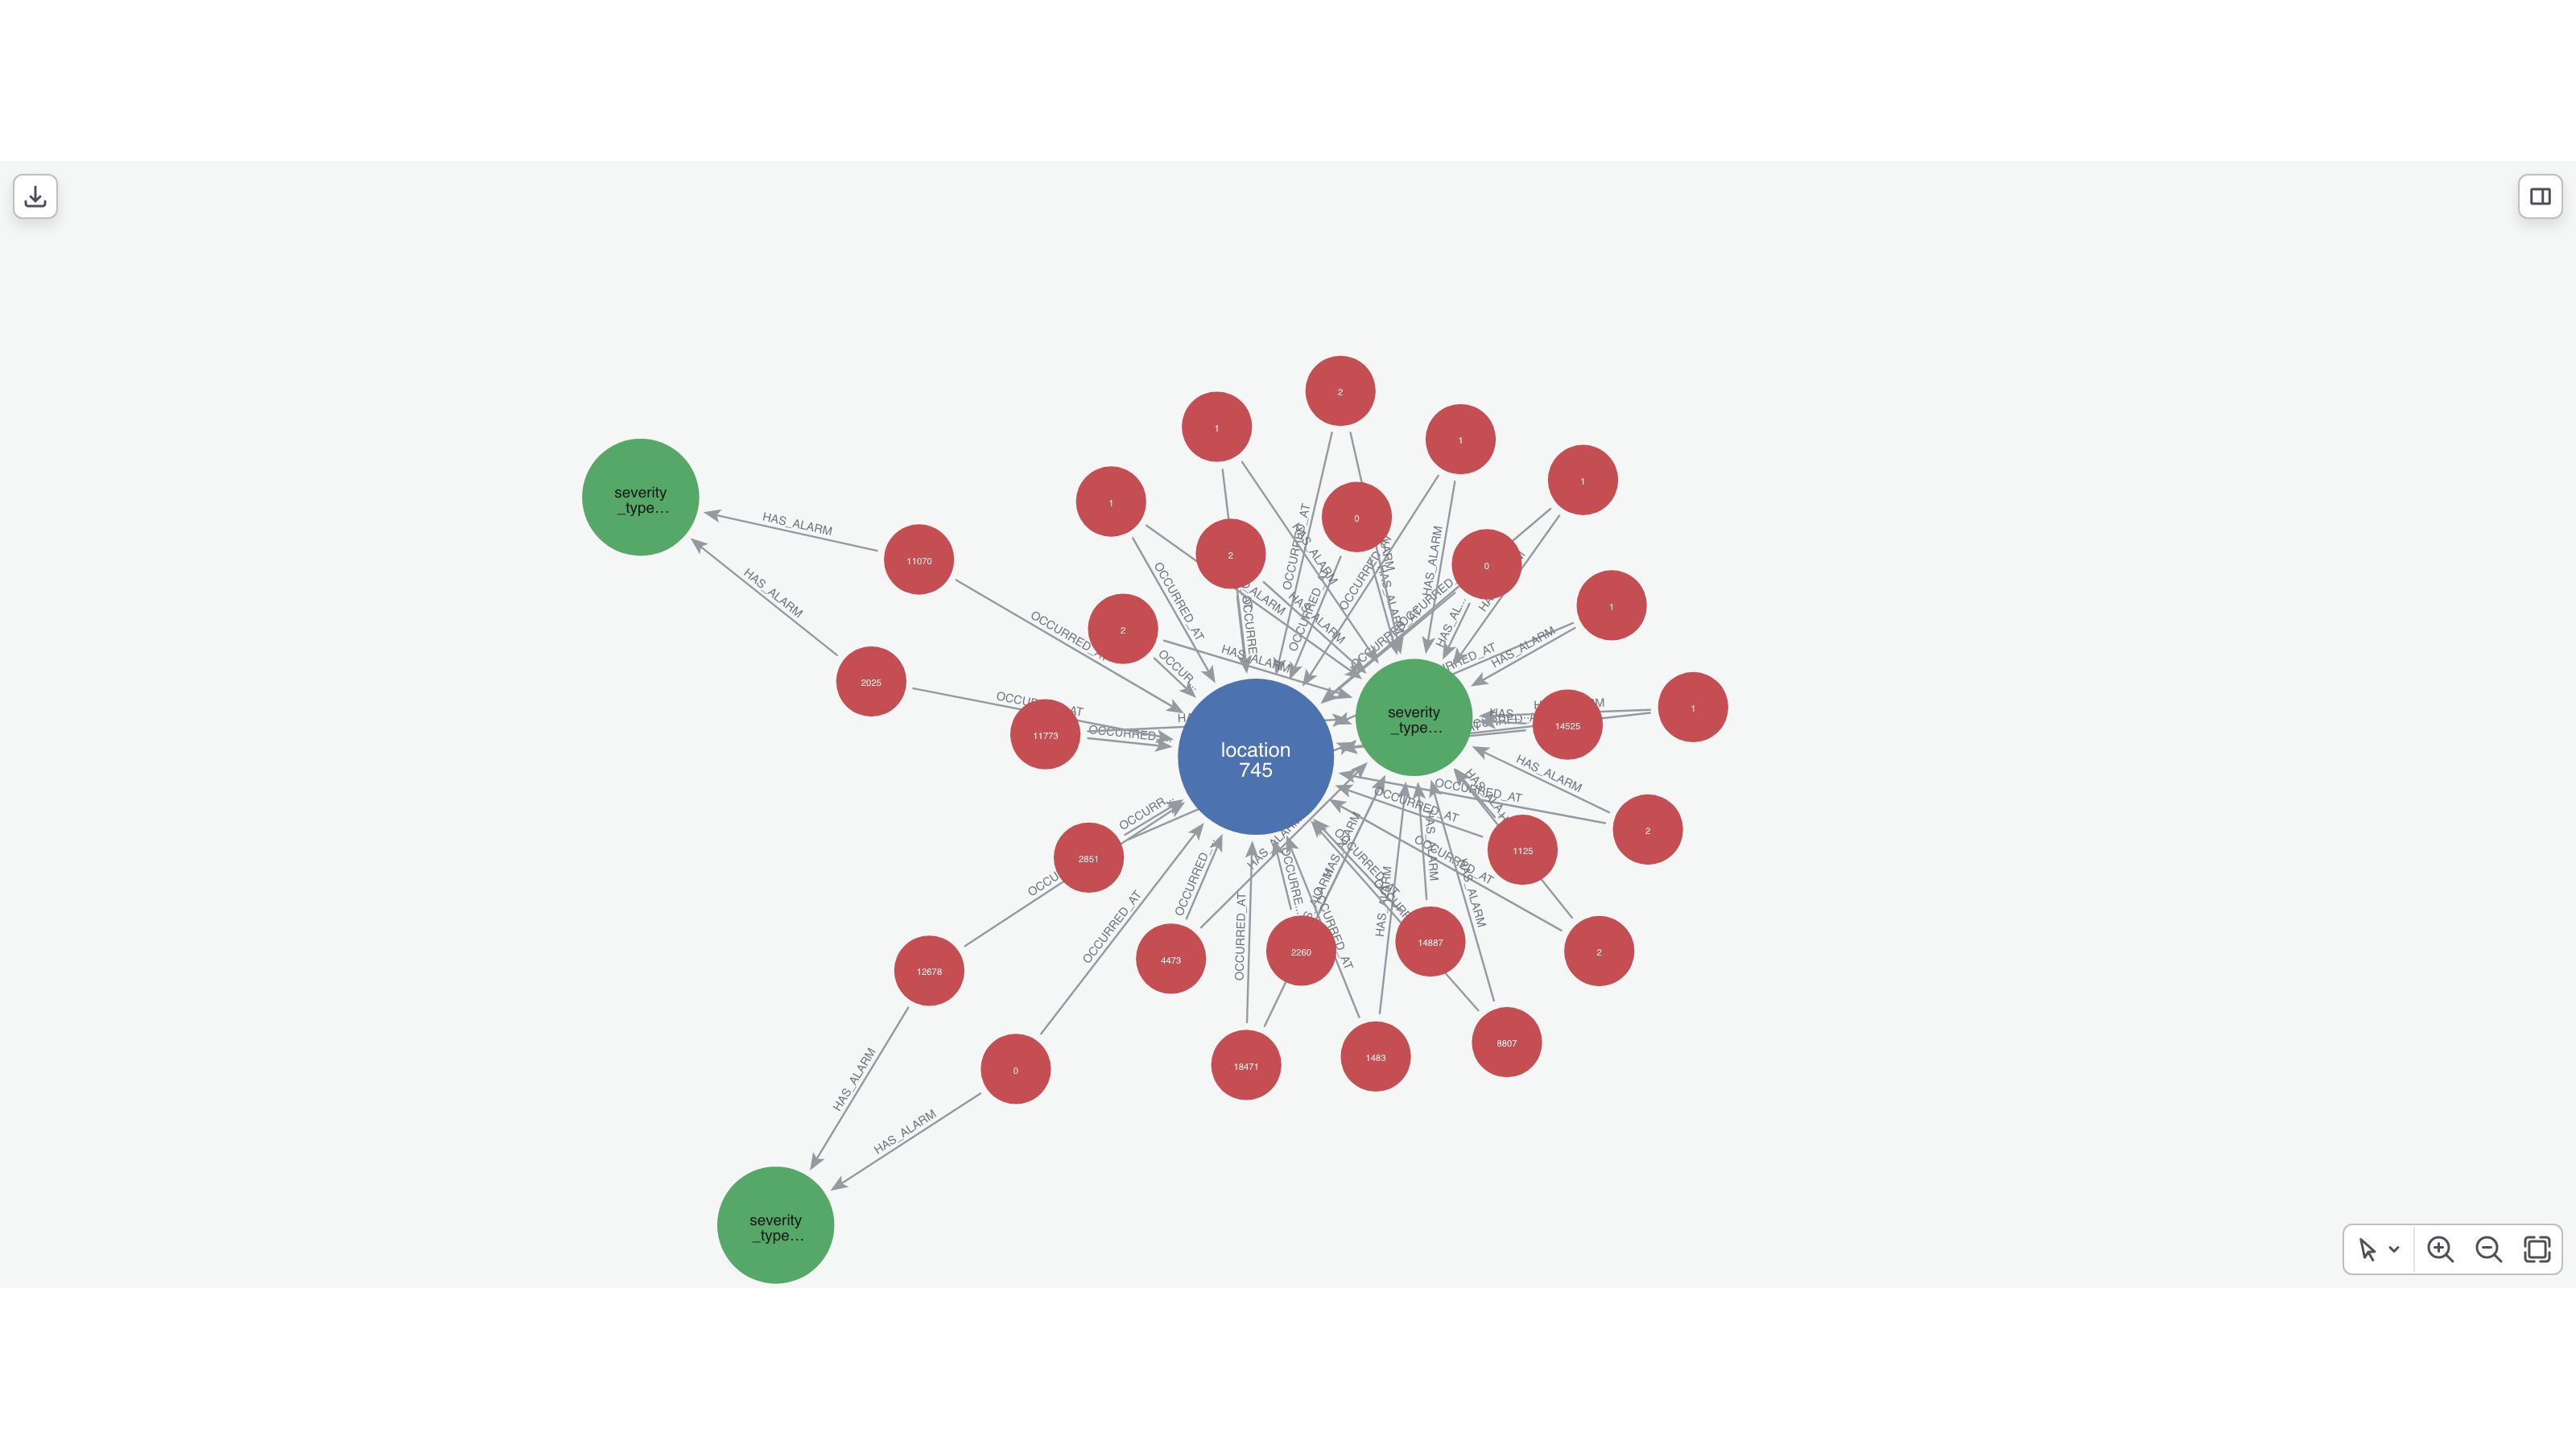

In [10]:
from neo4j_viz.neo4j import from_neo4j
from IPython.display import Image

# Pick a busy, fault-prone training location to visualise.
focus = graph.run_query('''
    MATCH (l:Location)<-[:OCCURRED_AT]-(e:DisruptionEvent {dataset:'train'})
    WITH l.name AS name, count(e) AS c,
         sum(CASE WHEN e.fault_severity=2 THEN 1 ELSE 0 END) AS sev2
    WHERE c >= 8 AND c <= 16 AND sev2 >= 1
    RETURN name ORDER BY sev2 DESC, c DESC LIMIT 1
''')[0]["name"]
print("Visualising", focus)

g = graph.run_query_viz('''
    MATCH p=(l:Location {name:$loc})<-[:OCCURRED_AT]-(e:DisruptionEvent)-[:HAS_ALARM]->(s:SeverityType)
    RETURN p
''', {"loc": focus})

VG = from_neo4j(g)
graph.set_caption_by_label(VG, {
    "Location": "name",
    "DisruptionEvent": "fault_severity",
    "SeverityType": "name",
})

# Colour and size nodes by label so the three node types read at a glance.
label_color = {"Location": "#4C72B0", "DisruptionEvent": "#C44E52", "SeverityType": "#55A868"}
label_size = {"Location": 40, "DisruptionEvent": 18, "SeverityType": 30}
for node in VG.nodes:
    lbl = (node.properties.get("labels") or ["?"])[0]
    node.color = label_color.get(lbl, "#999999")
    node.size = label_size.get(lbl, 15)

html = VG.render(layout="forcedirected", height="700px")
await graph.capture_graph_to_png(html, "location_subgraph.png", width=1600, height=900)
Image("location_subgraph.png")

In [11]:
graph.close()
print("Done — connection closed.")

Done — connection closed.
